In [33]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [34]:
class MyState(TypedDict):
    name: str
    age: int
    cgpa: float
    has_docs: bool
    fee_paid: bool
    validation_status: str
    eligibility_status: str
    category: str

In [35]:
def process_applications(state: MyState) -> MyState:
    name = state['name']
    age = state['age']
    cgpa = state['cgpa']
    has_docs = state['has_docs']
    fee_paid = state['fee_paid']

    if name is not None and age >= 18 and (cgpa > 0 and cgpa <= 4.0) and has_docs==True and fee_paid==True:
        state['validation_status'] = 'Valid' 
    else:
        state['validation_status'] = 'InValid'

    return state

In [36]:
def valid_application(state:MyState) -> MyState:
    status = state['validation_status'] 
    cgpa = state['cgpa']
    # eligibility_status = state['eligibility_status']

    if status == 'Valid':
        if cgpa >= 3.5:
            state['eligibility_status'] = 'Eligible'
        else:
            state['eligibility_status'] = 'Not Eligible'
    return state


In [37]:
def assign_category(state: MyState) -> MyState:
    cgpa = state['cgpa']

    if cgpa >=3.8 and cgpa <=4.0:
        state['category'] = 'Excellent'
    elif cgpa>=3.5 and cgpa <=3.79:
        state['category'] = 'Good'
    elif cgpa>=3.0 and cgpa<=3.49:
        state['category'] = 'Average'
    else:
        state['category'] = 'Below Average'

    return state

In [38]:
graph = StateGraph(MyState)

graph.add_node('process_applications', process_applications)
graph.add_node('valid_application', valid_application)
graph.add_node('assign_category', assign_category)

graph.add_edge(START, 'process_applications')
graph.add_edge('process_applications', 'valid_application')
graph.add_edge('valid_application', 'assign_category')
graph.add_edge('assign_category',END)

workflow =graph.compile()

final_state = workflow.invoke({'name':'Butterfly', 'age':23, 'cgpa':3.86, 'has_docs':True, 'fee_paid':True})

print(final_state['eligibility_status'])
print(final_state['category'])
print(final_state['validation_status'])

Eligible
Excellent
Valid


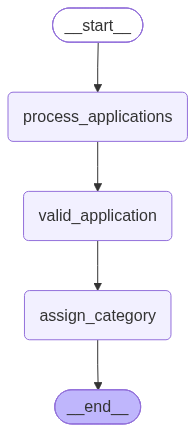

In [39]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())